# 05 Training a CNN on Image Datasets (CIFAR-10)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load **CIFAR-10**, preprocess it, and inspect shape and labels
- Build a small **CNN**, train it for a few epochs, and plot **loss/accuracy**
- Evaluate on the test set and see sample predictions

---

## 🌍 Real life

**Where is this used?** Training CNNs on image datasets is used in **product recognition**, **quality inspection**, and **medical image classification**.

**In this notebook we use** a **CNN** to **classify CIFAR-10** (32×32 color images, 10 classes). We use **CIFAR-10** (instead of ImageNet for this demo) **because** it is small and fast to train so you see the full pipeline in ~10 min.

**📌 Covers slide(s):** **11** — Image Segmentation / image pipelines (see README). *Do this notebook after core transfer-learning notebooks (05, 06).*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **CIFAR-10:** 50k train + 10k test, 32×32 RGB, 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
- **Pipeline:** Load data → normalize → build CNN (Conv2D, MaxPool, Dense) → compile → train → evaluate.
- **We use a CNN** (instead of MLP on flattened pixels) because images have **spatial structure**; conv layers preserve it.
- **We use a small subset or few epochs** here so the notebook runs in ~10 min; in real projects you'd train longer.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. CIFAR-10 (built-in). We use a subset or 3 epochs so it runs quickly.

**Dataset:** Real — CIFAR-10 (natural images, 10 classes).

**Outputs:** Training/validation loss and accuracy curves (with axis labels), test accuracy, and a few sample predictions (true → predicted).

## Step 1: Imports and load CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    y_train, y_test = y_train.flatten(), y_test.flatten()
    print("Train:", x_train.shape, "Test:", x_test.shape)
    print("Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)")
else:
    print("Install TensorFlow: pip install tensorflow")

170498071/170498071 [==============================] - 30s 0us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)
Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)


## Step 2: Build CNN (we use Conv2D + MaxPool for spatial structure instead of flattening first)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 64)                1

## Step 3: Train (3 epochs so it runs in ~5–10 min)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=1)

Epoch 1/3
352/352 [==============================] - 5s 14ms/step - loss: 1.6303 - accuracy: 0.4152 - val_loss: 1.3682 - val_accuracy: 0.5136
Epoch 2/3
352/352 [==============================] - 5s 13ms/step - loss: 1.2800 - accuracy: 0.5487 - val_loss: 1.2060 - val_accuracy: 0.5744
Epoch 3/3
352/352 [==============================] - 5s 14ms/step - loss: 1.1571 - accuracy: 0.5953 - val_loss: 1.1266 - val_accuracy: 0.6118


## Step 4: Plot loss and accuracy

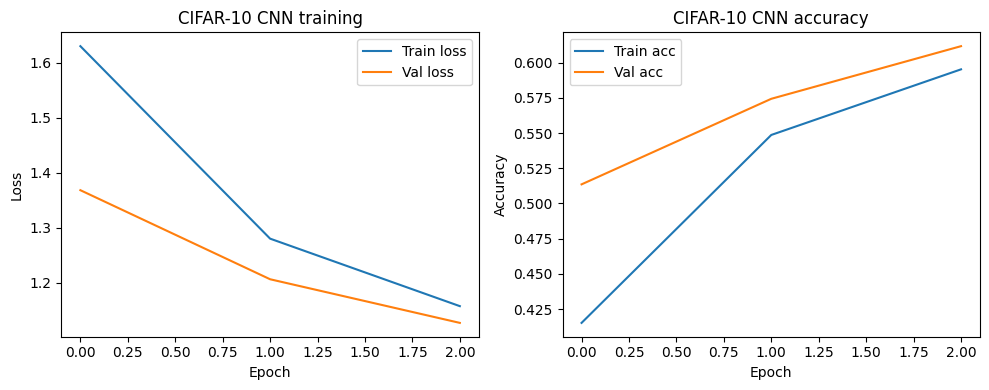

In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("CIFAR-10 CNN training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("CIFAR-10 CNN accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()

## Step 5: Evaluate and sample predictions

In [5]:
if HAS_TF:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % test_acc)
    preds = np.argmax(model.predict(x_test[:5]), axis=1)
    print("Sample (true → predicted):", list(zip(y_test[:5].tolist(), preds.tolist())))

Test accuracy: 0.6057
1/1 [==============================] - 0s 32ms/step
Sample (true → predicted): [(3, 3), (8, 1), (8, 1), (0, 0), (6, 6)]


## 🧩 Mini-exercise

**Try it (choose one):** Add simple data augmentation (e.g. random flip or small rotation) before training and run for 2 epochs. Does test accuracy change? Or increase epochs to 5 and see if the model starts to overfit.

---

## ✅ Summary

**What you did:** Loaded CIFAR-10, built a CNN, trained for 3 epochs, plotted loss/accuracy, and evaluated with sample predictions.

**In real life you'd also:** Use data augmentation, more epochs, learning rate scheduling, and early stopping.

**The main idea:** Training a CNN on an image dataset follows: load → preprocess → build CNN → train → evaluate; we use conv layers to exploit spatial structure.

**Next:** `04_transfer_learning_object_detection` extends transfer learning to object detection; `01_cnn_architecture` introduces CNN layers.